# Segunda entrega — Proceso ETL y preparación del dataset objetivo
**Calidad del aire en CABA — Ciencia de Datos, UTN FRC, Grupo 12**

Contenido:
1. Carga de las fuentes (extracción de la primera entrega)
2. Análisis y comprensión de los datos: calidad (erróneos, faltantes, inconsistentes)
3. Visualización y análisis estadístico
4. Estrategia para cada caso
5. Unificación de fuentes y selección de filas/columnas
6. Dataset objetivo

Todo el proceso es reproducible con `.\run.ps1 join` (unificación) y `.\run.ps1 transform` (limpieza). La lógica está en `aire_caba/transform.py`; este notebook la ejecuta y documenta.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from aire_caba import transform as T

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
pd.set_option("display.max_columns", 40)
STATIONS = ["CENTENARIO", "CORDOBA", "LA_BOCA", "PALERMO"]
POLS = list(T.POLLUTANTS)

## 1. Fuentes

| Fuente | Archivo | Granularidad | Origen |
|---|---|---|---|
| Calidad del aire (APrA, Buenos Aires Data) | `data/raw/air/.../calidad-aire.csv` | FECHA/HORA, formato ancho (4 estaciones × CO, NO2, PM10) | CSV oficial |
| Meteorología (Open-Meteo, ERA5) | `data/exports/meteorologia.csv` | estación/hora | API, primera entrega |
| Calendario y feriados | `data/exports/calendario.csv`, `feriados.csv` | día | biblioteca `holidays` + ajustes |
| Unificación | `data/exports/entrada_transformacion.csv` | fila del CSV de aire (left join) | `run.ps1 join` |

Unidades de contaminantes: CO en ppm, NO2 en ppb, PM10 en µg/m³.

In [2]:
raw = pd.read_csv(next((ROOT / "data/raw/air").glob("*/calidad-aire.csv")), dtype=str, keep_default_na=False)
entrada = pd.read_csv(ROOT / "data/exports/entrada_transformacion.csv", dtype=str, keep_default_na=False, encoding="utf-8-sig")
print("Aire (original):", raw.shape, "| Entrada unificada:", entrada.shape)
raw.head()

Aire (original): (145980, 14) | Entrada unificada: (145980, 89)


,FECHA,HORA,CO_CENTENARIO,NO2_CENTENARIO,PM10_CENTENARIO,CO_CORDOBA,NO2_CORDOBA,PM10_CORDOBA,CO_LA_BOCA,NO2_LA_BOCA,PM10_LA_BOCA,CO_PALERMO,NO2_PALERMO,PM10_PALERMO
0,03JAN2021:00:00:00,6,0.35,5,22,0.33,35,16,s/d,5,19,,,
1,03JAN2021:00:00:00,11,0.28,3,21,0.23,37,14,s/d,4,16,,,
2,16JAN2021:00:00:00,16,0.37,12,25,0.63,18,23,s/d,10,24,,,
3,17JAN2021:00:00:00,5,0.23,5,19,0.44,6,22,s/d,4,19,,,
4,17JAN2021:00:00:00,9,0.19,3,16,0.28,3,19,s/d,4,15,,,


## 2. Análisis de calidad de los datos
### 2.1 Tipos de contenido por celda
Cada celda de contaminante se clasifica en: número, valor censurado (`<0.05`), marcador de faltante (`s/d`, `x/d`), vacío o error de planilla (`#REF!`).

In [3]:
states = {c: T.classify(raw[c])[1].value_counts() for c in raw.columns[2:]}
tipos = pd.DataFrame(states).T.fillna(0).astype(int)[["medido", "censurado", "sin_dato", "vacio", "error"]]
tipos["% utilizable"] = ((tipos.medido + tipos.censurado) / len(raw) * 100).round(1)
tipos

,medido,censurado,sin_dato,vacio,error,% utilizable
CO_CENTENARIO,115975,21,29643,293,48,79.5
NO2_CENTENARIO,116233,0,29431,292,24,79.6
PM10_CENTENARIO,118337,0,17022,10597,24,81.1
CO_CORDOBA,110542,1774,33323,293,48,76.9
NO2_CORDOBA,97127,0,48536,293,24,66.5
PM10_CORDOBA,99586,0,35773,10597,24,68.2
CO_LA_BOCA,102338,8664,34639,291,48,76.0
NO2_LA_BOCA,119842,0,25822,292,24,82.1
PM10_LA_BOCA,114736,0,20626,10594,24,78.6
CO_PALERMO,5942,0,60,139978,0,4.1


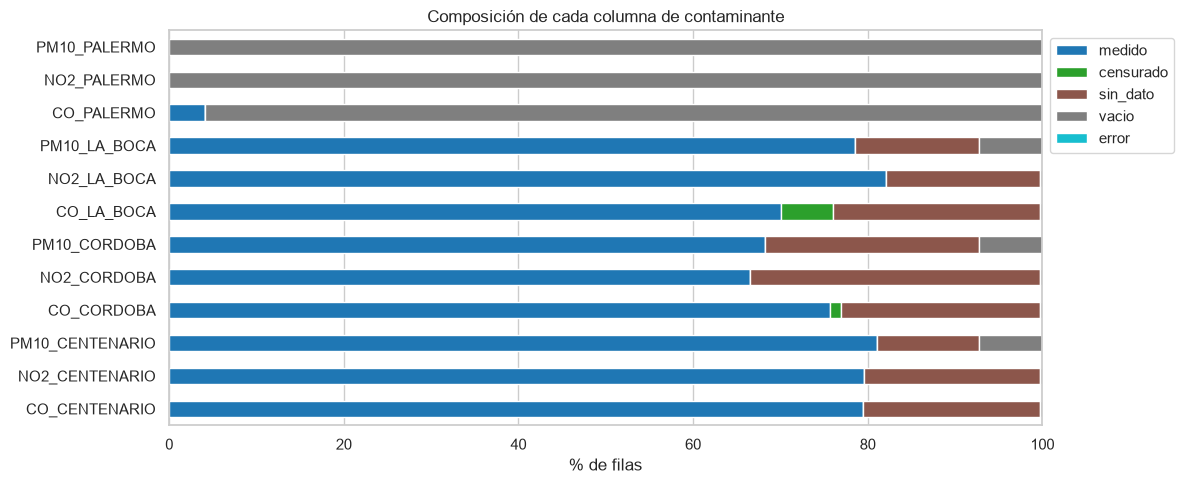

In [4]:
ax = (tipos.drop(columns="% utilizable").div(len(raw)) * 100).plot.barh(stacked=True, figsize=(12, 5), colormap="tab10")
ax.set_xlabel("% de filas"); ax.set_title("Composición de cada columna de contaminante"); ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()

**Observaciones**
- Palermo sólo tiene CO (≈4% de filas, 2009–2010); NO2 y PM10 están 100% vacíos.
- `s/d` es el faltante dominante (12–33% según la columna). Hay variantes inconsistentes: `S/d`, `x/d`.
- PM10 tiene ≈10.600 vacíos: corresponden a 2009–2010, antes de que comenzara la medición de PM10.
- `#REF!` (288 celdas) es un error de planilla concentrado en 4 días (25–26/02/2020 y 17–18/05/2024).
- Valores censurados (`<0.05`, `<0.04`, `< 0.05`, `<0.5`): límite de detección de CO, muy frecuente en La Boca (8.664).

### 2.2 Claves temporales: horas inválidas, duplicados y huecos

In [5]:
fecha = pd.to_datetime(raw.FECHA, format="%d%b%Y:%H:%M:%S")
hora = pd.to_numeric(raw.HORA)
invalid = ~hora.between(1, 24)
datos_en_invalidas = sum(T.classify(raw.loc[invalid, c])[0].notna().sum() for c in raw.columns[2:])
print(f"HORA=0: {(hora == 0).sum()} | HORA>24: {(hora > 24).sum()} | mediciones en esas filas: {datos_en_invalidas}")
print("Duplicados FECHA/HORA:", raw.duplicated(["FECHA", "HORA"]).sum())
fh = fecha[~invalid] + pd.to_timedelta(hora[~invalid], unit="h")
print("Duplicados tras normalizar a instante:", fh.duplicated().sum())
grid = pd.date_range(fh.min(), fh.max(), freq="h")
print(f"Horas esperadas: {len(grid)} | presentes: {fh.nunique()} | ausentes: {len(grid) - fh.nunique()}")
print("¿Archivo ordenado cronológicamente?", fh.is_monotonic_increasing)

HORA=0: 147 | HORA>24: 135 | mediciones en esas filas: 0
Duplicados FECHA/HORA: 0
Duplicados tras normalizar a instante: 0
Horas esperadas: 148100 | presentes: 145698 | ausentes: 2402
¿Archivo ordenado cronológicamente? False


- La columna HORA usa la convención 1–24 (hora de cierre del promedio). HORA=0 y HORA>24 son **filas inconsistentes** pero están vacías: se eliminan sin pérdida de información.
- No hay duplicados, ni siquiera al convertir HORA=24 a las 00 del día siguiente.
- Faltan 2.402 horas en la grilla completa (filas no publicadas). El archivo está desordenado: se ordena por instante.

### 2.3 Cobertura temporal por estación y contaminante

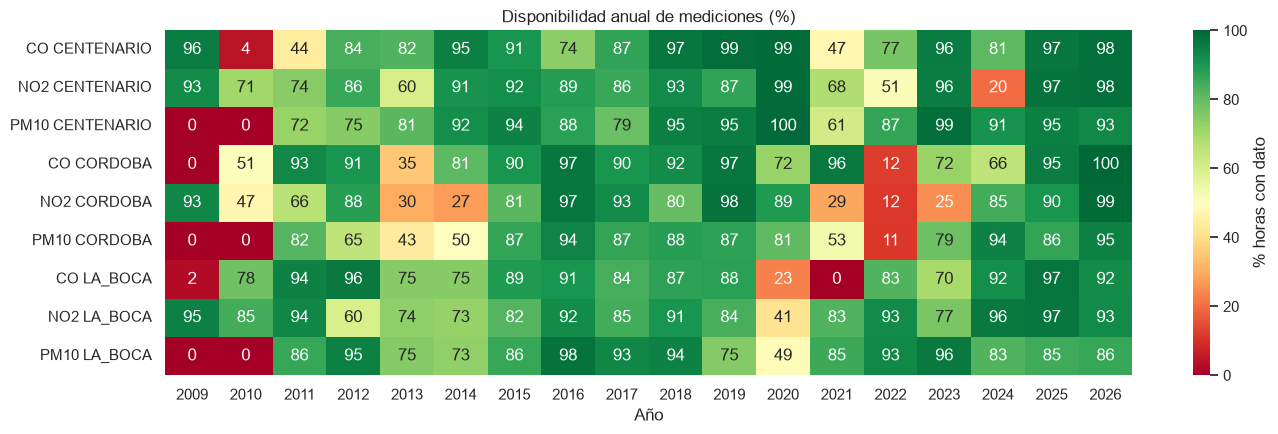

In [6]:
cov = {}
for s in STATIONS[:3]:
    for p in POLS:
        v, st = T.classify(raw[f"{p}_{s}"])
        cov[f"{p} {s}"] = v.notna().groupby(fecha.dt.year).mean() * 100
cov = pd.DataFrame(cov).T
plt.figure(figsize=(14, 4.5))
sns.heatmap(cov, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100, cbar_kws={"label": "% horas con dato"})
plt.title("Disponibilidad anual de mediciones (%)"); plt.xlabel("Año"); plt.tight_layout()

Hay años con muy baja disponibilidad (p. ej. CO La Boca 2021, NO2/PM10 Córdoba 2022). Los faltantes no son aleatorios: forman bloques largos (equipos fuera de servicio), lo que condiciona la estrategia de imputación.

In [7]:
def gap_lengths(values):
    miss = values.isna()
    run = (miss != miss.shift()).cumsum()
    return miss.groupby(run).sum()[lambda x: x > 0]

rows = []
idx = pd.Index(fh.values)
for s in STATIONS[:3]:
    for p in POLS:
        v = T.classify(raw.loc[~invalid, f"{p}_{s}"])[0].set_axis(idx).sort_index().reindex(grid)
        g = gap_lengths(v)
        rows.append({"serie": f"{p} {s}", "huecos": len(g), "≤3 h": (g <= 3).sum(), "4–24 h": g.between(4, 24).sum(),
                     "> 24 h": (g > 24).sum(), "% horas en huecos > 24 h": round(g[g > 24].sum() / g.sum() * 100, 1)})
gaps = pd.DataFrame(rows).set_index("serie"); gaps

,huecos,≤3 h,4–24 h,> 24 h,% horas en huecos > 24 h
serie,,,,,
CO CENTENARIO,340,5,250,85,91.6
NO2 CENTENARIO,1120,804,214,102,88.1
PM10 CENTENARIO,223,6,96,121,93.1
CO CORDOBA,284,8,187,89,93.3
NO2 CORDOBA,589,352,139,98,95.2
PM10 CORDOBA,265,2,88,175,96.1
CO LA_BOCA,366,19,209,138,92.1
NO2 LA_BOCA,712,396,191,125,87.9
PM10 LA_BOCA,225,3,95,127,93.7


La mayoría de los **huecos** son cortos (≤ 3 h), pero casi todas las **horas faltantes** pertenecen a huecos de más de un día. Interpolar sólo huecos cortos recupera datos sin inventar episodios completos.

### 2.4 Valores erróneos y atípicos

In [8]:
num = pd.DataFrame({f"{p}_{s}": T.classify(raw[f"{p}_{s}"])[0] for s in STATIONS[:3] for p in POLS})
desc = num.describe(percentiles=[.01, .5, .99, .999]).T
desc["negativos"] = (num < 0).sum(); desc["ceros"] = (num == 0).sum()
desc.round(2)

,count,mean,std,min,1%,50%,99%,99.9%,max,negativos,ceros
CO_CENTENARIO,115996.0,0.54,0.84,0.0,0.15,0.46,1.45,3.60,49.95,0,83
NO2_CENTENARIO,116233.0,18.01,9.14,-2.0,4.00,17.00,46.00,66.77,155.00,1,100
PM10_CENTENARIO,118337.0,25.43,14.03,0.0,8.00,23.00,71.00,150.00,427.00,0,80
CO_CORDOBA,112316.0,0.61,0.98,0.0,0.02,0.53,1.81,3.26,47.29,0,60
NO2_CORDOBA,97127.0,23.59,14.27,0.0,3.00,21.00,73.00,122.87,283.00,0,206
PM10_CORDOBA,99586.0,26.03,13.06,0.0,8.00,24.00,70.00,154.41,253.00,0,121
CO_LA_BOCA,111002.0,0.37,1.09,0.0,0.02,0.29,1.39,25.35,44.73,0,61
NO2_LA_BOCA,119842.0,20.96,11.96,0.0,3.00,19.00,57.00,77.00,129.00,0,76
PM10_LA_BOCA,114736.0,27.90,15.41,0.0,9.00,25.00,82.00,156.00,387.00,0,104


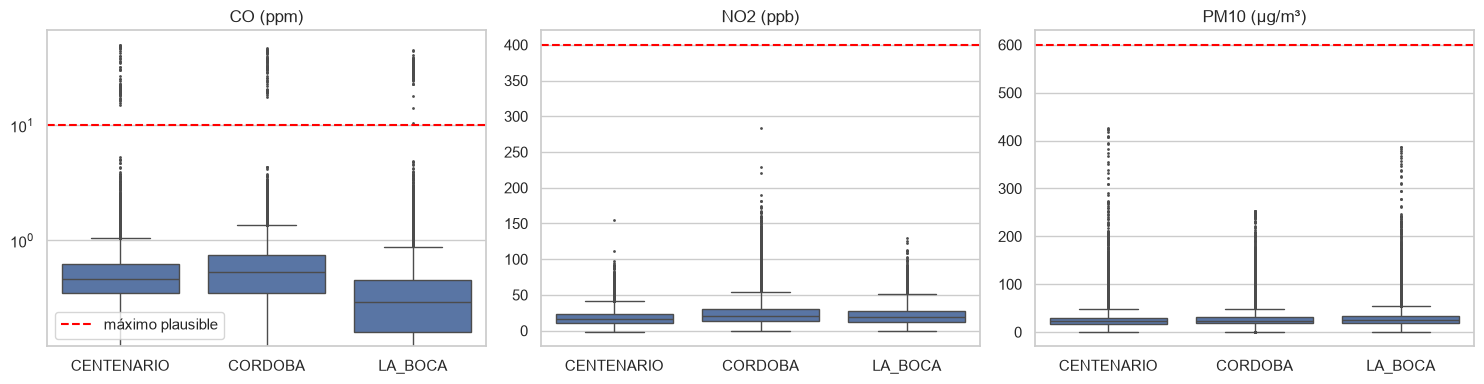

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, p in zip(axes, POLS):
    data = pd.melt(num[[f"{p}_{s}" for s in STATIONS[:3]]].rename(columns=lambda c: c.split("_", 1)[1]))
    sns.boxplot(data=data, x="variable", y="value", ax=ax, fliersize=1)
    ax.axhline(T.VALID_RANGE[p][1], color="red", ls="--", label="máximo plausible")
    ax.set(title=f"{p} ({T.POLLUTANTS[p]})", xlabel="", ylabel="", yscale="log" if p == "CO" else "linear")
axes[0].legend(); plt.tight_layout()

Días con CO > 10 ppm: ['2010-10-25', '2010-10-26', '2014-06-23', '2014-06-24', '2014-12-23', '2014-12-24', '2018-02-16', '2018-02-17', '2018-07-31', '2018-08-01', '2022-10-18', '2022-10-19', '2026-06-01']


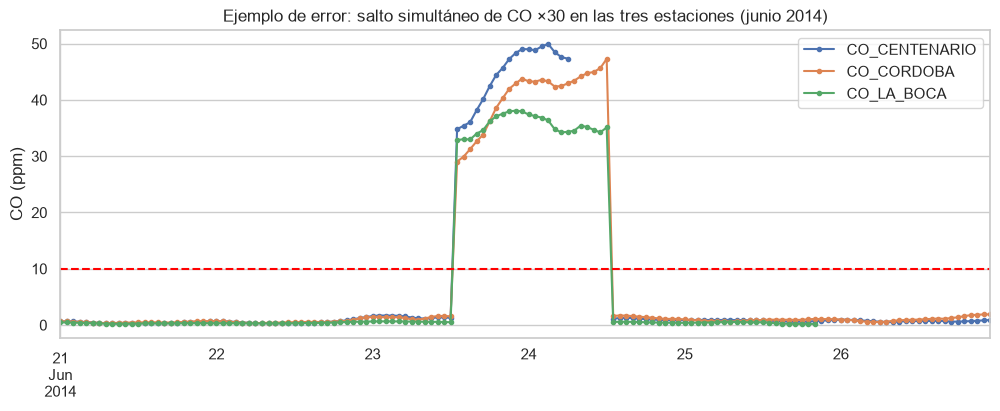

In [10]:
co = num[["CO_CENTENARIO", "CO_CORDOBA", "CO_LA_BOCA"]].set_axis(pd.Index(fecha + pd.to_timedelta(hora, unit="h"))).sort_index()
ventana = co.loc["2014-06-21":"2014-06-26"]
ax = ventana.plot(figsize=(12, 4), marker=".", title="Ejemplo de error: salto simultáneo de CO ×30 en las tres estaciones (junio 2014)")
ax.set_ylabel("CO (ppm)"); ax.axhline(10, color="red", ls="--");
print("Días con CO > 10 ppm:", sorted({d.date().isoformat() for d in co[(co > 10).any(axis=1)].index}))

**Valores erróneos detectados**
- **CO > 10 ppm**: bloques de 12–24 h en los que CO salta ~30 veces *en las tres estaciones a la vez* (2010, 2014, 2018, 2022). No es un fenómeno físico (NO2 no acompaña): es un error de escala/registro.
- **NO2 negativo** (−2 ppb): imposible físicamente.
- **PM10 = 0**: un promedio horario urbano nulo no es plausible (incluye 12 filas de 2010 con todo en 0).
- **Valores congelados**: el mismo valor medido ≥ 24 h seguidas indica sensor trabado.

Los valores altos pero plausibles (p. ej. PM10 de 300–400 µg/m³ en episodios de humo) **no se eliminan**: son la señal de interés.

In [11]:
def flatlines(p, s):
    v, st = T.classify(raw.loc[~invalid, f"{p}_{s}"])
    v, st = v.set_axis(idx).sort_index().reindex(grid), st.set_axis(idx).sort_index().reindex(grid)
    return int(T.flatline(v, st).sum())
pd.DataFrame({p: {s: flatlines(p, s) for s in STATIONS[:3]} for p in POLS}).rename_axis("horas congeladas ≥24 h")

,CO,NO2,PM10
horas congeladas ≥24 h,,,
CENTENARIO,111,48,481
CORDOBA,116,48,418
LA_BOCA,74,72,446


Conteo sobre los datos originales; en el pipeline las rachas de PM10 = 0 se cuentan como `fuera_rango`, por eso el total final de `congelado` es algo menor.

### 2.5 Calidad de las fuentes externas (meteorología y calendario)

In [12]:
meta_join = json.loads((ROOT / "data/exports/entrada_transformacion.meta.json").read_text(encoding="utf-8"))
print("Filas de aire con meteorología asociada:", meta_join["weather_matches"])
print("Sin asociación:", meta_join["weather_unmatched"])
print("Sin calendario:", meta_join["calendar_unmatched"])
met = pd.DataFrame({v: pd.to_numeric(entrada[f"METEO_CENTENARIO_{v}"], errors="coerce") for v in T.METEO_RANGE})
fuera = {v: int(((met[v] < lo) | (met[v] > hi)).sum()) for v, (lo, hi) in T.METEO_RANGE.items()}
display(met.describe().T.round(2).assign(fuera_de_rango=pd.Series(fuera)))
print("Estados meteorológicos:", entrada.METEO_CENTENARIO_estado.value_counts().to_dict())

Filas de aire con meteorología asociada: {'centenario': 145387, 'cordoba': 133397, 'la_boca': 145845, 'palermo': 7777}
Sin asociación: {'centenario': 593, 'cordoba': 12583, 'la_boca': 135, 'palermo': 138203}
Sin calendario: 0


,count,mean,std,min,25%,50%,75%,max,fuera_de_rango
temperature_2m,145387.0,17.67,5.95,0.1,13.1,17.70,22.20,37.00,0
relative_humidity_2m,145387.0,72.82,14.25,22.0,63.0,75.00,84.00,100.00,0
surface_pressure,145387.0,1013.69,6.31,991.3,1009.3,1013.40,1017.80,1039.90,0
wind_speed_10m,145387.0,4.49,1.94,0.0,3.1,4.29,5.71,16.43,0
wind_direction_10m,145387.0,153.87,104.88,0.0,68.0,128.00,233.00,360.00,0
precipitation,145387.0,0.11,0.58,0.0,0.0,0.00,0.00,18.00,0
cloud_cover,145387.0,45.58,41.07,0.0,1.0,38.00,93.00,100.00,0
shortwave_radiation,145387.0,201.84,289.58,0.0,0.0,6.00,359.00,1121.00,0


Estados meteorológicos: {'disponible': 145387, '': 593}


- La meteorología ERA5 no tiene nulos ni valores fuera de rango. Las filas sin asociación son horas inválidas o años en que la estación no midió (Palermo después de 2010, Córdoba en 2009): no tienen contaminantes, así que no afectan al dataset final.
- Centenario y Córdoba comparten la celda ERA5 (~25 km): su meteorología es casi idéntica; no son observaciones independientes.
- El calendario cubre el 100% de las fechas. Una fila (12/10/2009) carece del campo `metodo`, que no se usa.

## 3. Visualización y análisis estadístico
Se usan los datos ya depurados (sección 5) para que los errores no distorsionen los estadísticos.

In [13]:
meta = T.transform_dataset(ROOT / "data")
df = pd.read_csv(ROOT / "data/exports/dataset_objetivo.csv", encoding="utf-8-sig", parse_dates=["fecha_hora"])
print(df.shape)
df.groupby("estacion")[POLS].describe().T.round(2)

(398961, 27)


estacion    centenario    cordoba    la_boca
CO   count   115788.00  112115.00  110849.00
     mean         0.52       0.59       0.34
     std          0.26       0.35       0.27
     min          0.00       0.00       0.00
     25%          0.35       0.35       0.16
     50%          0.46       0.53       0.29
     75%          0.63       0.75       0.45
     max          5.28       4.36       4.93
NO2  count   117678.00   97655.00  120447.00
     mean        18.05      23.63      20.98
     std          9.12      14.28      11.95
     min          0.00       0.00       0.00
     25%         11.00      14.00      12.00
     50%         17.00      21.00      19.00
     75%         23.00      30.00      28.00
     max        155.00     283.00     129.00
PM10 count   117866.00   99148.00  114267.00
     mean        25.48      26.10      27.97
     std         14.03      13.04      15.40
     min          1.00       1.00       1.00
     25%         18.00      19.00      19.00
     50%         23.00      24.00      25.00
     75%         30.00      31.00      33.00
     max        427.00     253.00     387.00

### 3.1 Antes y después de la limpieza

Los gráficos siguientes comparan las **mismas estaciones y horas que se conservan en el dataset objetivo**. El antes proviene de la entrada unificada y el después del resultado de `transform_dataset`. Las filas descartadas se informan por separado en la tabla: no se atribuye su eliminación a la recuperación de datos.

Para poder graficar el antes, se interpretan los números, se representan los marcadores de faltante como `NaN` y se sustituyen los valores censurados por `LD/2`, igual que en el análisis inicial. **Todavía no se invalidan valores fuera de rango ni sensores congelados, ni se interpolan huecos.** Por ello, la comparación muestra el efecto de esas últimas operaciones, no un antes sin ninguna conversión.

- **Distribuciones:** boxplots antes/después para cada estación y contaminante, con los atípicos visibles. CO usa una escala simétrica logarítmica para mostrar tanto la distribución habitual como los errores extremos.
- **Faltantes:** porcentajes sobre el mismo número de filas por estación. No tienen por qué disminuir: invalidar errores genera faltantes y la interpolación recupera únicamente huecos internos de hasta 3 horas.
- **Serie temporal de CO:** el episodio del 21 al 26 de junio de 2014 se muestra lado a lado, con idénticos ejes y el umbral de 10 ppm. La grilla horaria evita unir con una línea los intervalos sin datos.

Los valores altos pero físicamente plausibles no se eliminan por ser atípicos.

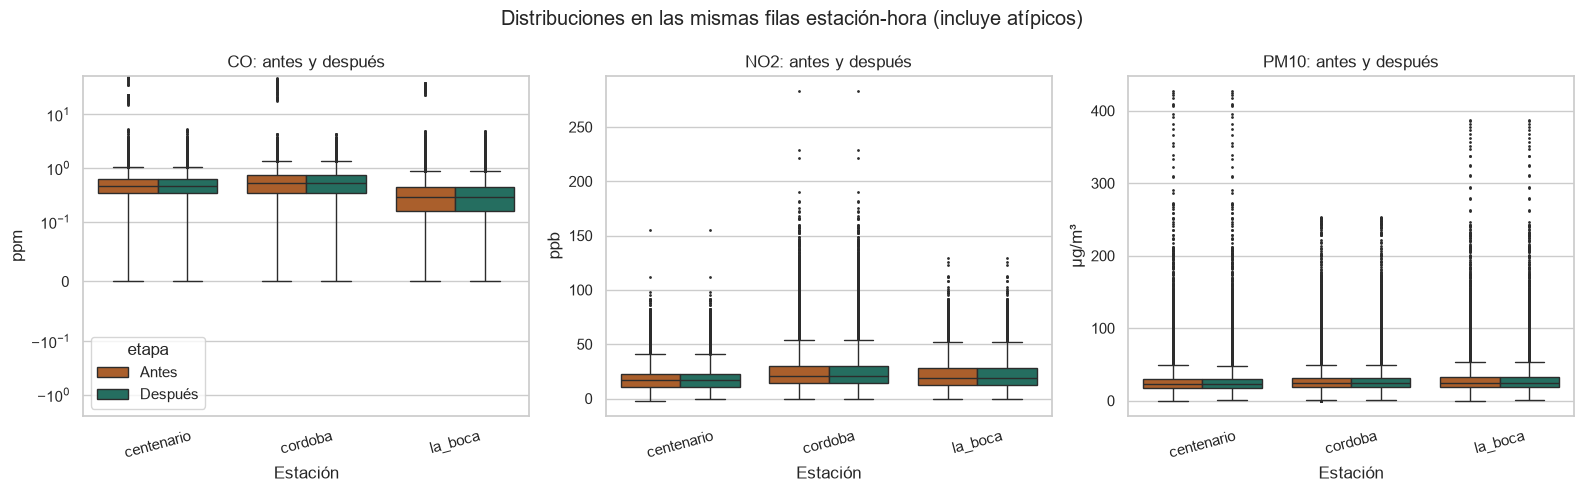

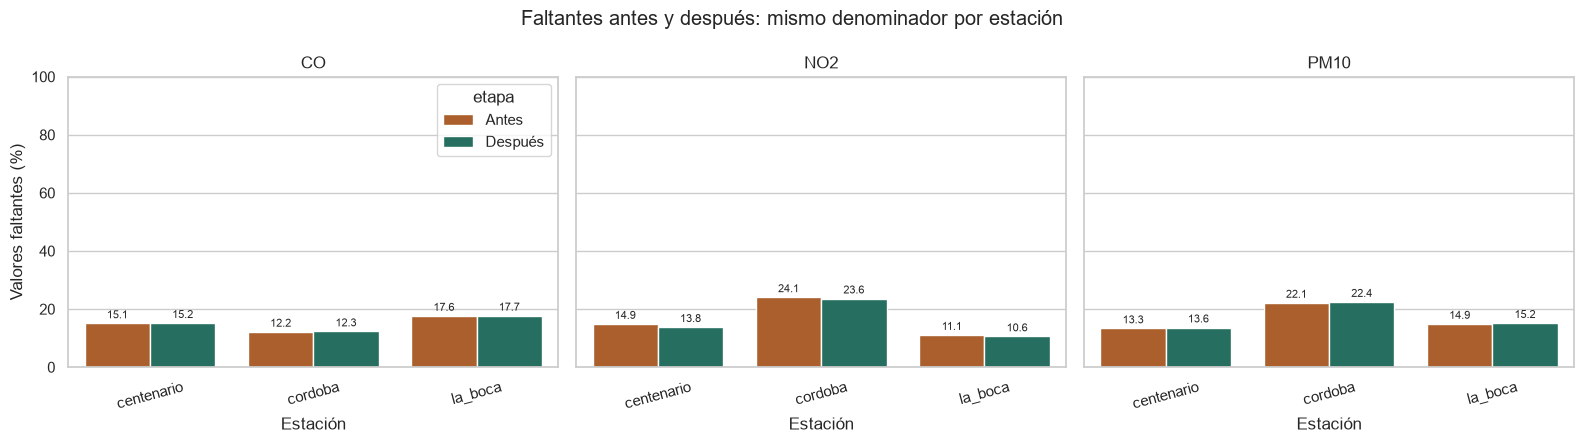

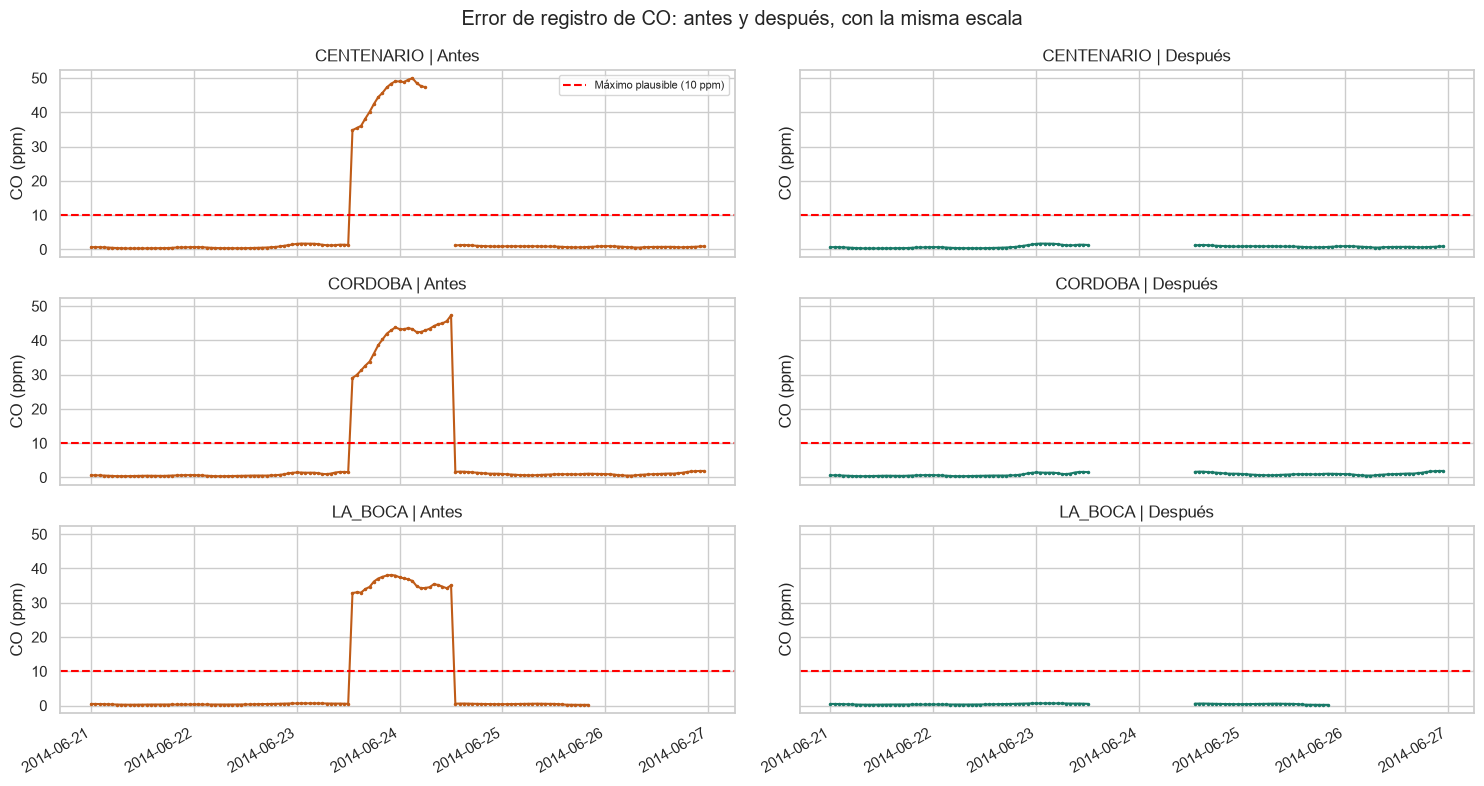

,"filas antes (horas válidas, 3 estaciones)",filas después,filas descartadas
estacion,,,
centenario,145698,136462,9236
cordoba,145698,127820,17878
la_boca,145698,134679,11019


Filas comparadas en cada etapa: 398961
El antes convierte marcadores a NaN y censurados a LD/2; aún conserva errores de rango y sensores congelados.
Los faltantes pueden aumentar al invalidar errores y disminuir al interpolar huecos cortos; los huecos largos se conservan.


In [14]:
fechas_entrada = pd.to_datetime(entrada["FECHA"], format="%d%b%Y:%H:%M:%S")
horas_entrada = pd.to_numeric(entrada["HORA"], errors="coerce")
horas_validas = horas_entrada.between(1, 24)
instantes = fechas_entrada[horas_validas] + pd.to_timedelta(horas_entrada[horas_validas], unit="h")

originales = []
for estacion in T.STATIONS:
    valores = pd.DataFrame({p: T.classify(entrada.loc[horas_validas, f"{p}_{estacion}"])[0] for p in POLS})
    valores["estacion"] = estacion.lower()
    valores["fecha_hora"] = instantes
    originales.append(valores)
antes_completo = pd.concat(originales).set_index(["estacion", "fecha_hora"]).sort_index()
despues = df.set_index(["estacion", "fecha_hora"])[POLS].sort_index()
assert antes_completo.index.is_unique and despues.index.is_unique
assert despues.index.isin(antes_completo.index).all()
antes = antes_completo.reindex(despues.index)[POLS]
assert antes.index.equals(despues.index)

comparacion = pd.concat([
    antes.reset_index().assign(etapa="Antes"),
    despues.reset_index().assign(etapa="Después"),
], ignore_index=True)
colores_etapas = {"Antes": "#bf5b17", "Después": "#197a68"}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, contaminante in zip(axes, POLS):
    sns.boxplot(data=comparacion, x="estacion", y=contaminante, hue="etapa",
                hue_order=["Antes", "Después"], palette=colores_etapas, fliersize=1, ax=ax)
    ax.set(title=f"{contaminante}: antes y después", xlabel="Estación", ylabel=T.POLLUTANTS[contaminante])
    ax.tick_params(axis="x", rotation=15)
    if contaminante == "CO":
        ax.set_yscale("symlog", linthresh=0.1)
    if contaminante != POLS[0]:
        ax.get_legend().remove()
fig.suptitle("Distribuciones en las mismas filas estación-hora (incluye atípicos)")
plt.tight_layout()
plt.show()

faltantes_comparados = pd.concat([
    antes.isna().groupby(level="estacion").mean().mul(100).assign(etapa="Antes"),
    despues.isna().groupby(level="estacion").mean().mul(100).assign(etapa="Después"),
]).reset_index().melt(id_vars=["estacion", "etapa"], value_vars=POLS,
                      var_name="contaminante", value_name="porcentaje")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, contaminante in zip(axes, POLS):
    sns.barplot(data=faltantes_comparados[faltantes_comparados.contaminante.eq(contaminante)],
                x="estacion", y="porcentaje", hue="etapa", hue_order=["Antes", "Después"],
                palette=colores_etapas, ax=ax)
    ax.set(title=contaminante, xlabel="Estación", ylabel="Valores faltantes (%)", ylim=(0, 100))
    ax.tick_params(axis="x", rotation=15)
    for barras in ax.containers:
        ax.bar_label(barras, fmt="%.1f", fontsize=8, padding=2)
    if contaminante != POLS[0]:
        ax.get_legend().remove()
fig.suptitle("Faltantes antes y después: mismo denominador por estación")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(15, 8), sharex=True, sharey=True)
for fila, estacion in enumerate(T.STATIONS):
    for columna, (etapa, datos) in enumerate([("Antes", antes), ("Después", despues)]):
        serie = datos.xs(estacion.lower())["CO"].loc["2014-06-21":"2014-06-26"]
        serie = serie.reindex(pd.date_range("2014-06-21", "2014-06-26 23:00", freq="h"))
        axes[fila, columna].plot(serie.index, serie, marker=".", markersize=3, color=colores_etapas[etapa])
        axes[fila, columna].axhline(T.VALID_RANGE["CO"][1], color="red", ls="--", label="Máximo plausible (10 ppm)")
        axes[fila, columna].set(title=f"{estacion} | {etapa}", ylabel="CO (ppm)")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Error de registro de CO: antes y después, con la misma escala")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

resumen_comparacion = pd.DataFrame({
    "filas antes (horas válidas, 3 estaciones)": antes_completo.groupby(level="estacion").size(),
    "filas después": despues.groupby(level="estacion").size(),
})
resumen_comparacion["filas descartadas"] = resumen_comparacion.iloc[:, 0] - resumen_comparacion.iloc[:, 1]
display(resumen_comparacion)
print("Filas comparadas en cada etapa:", len(antes))
print("El antes convierte marcadores a NaN y censurados a LD/2; aún conserva errores de rango y sensores congelados.")
print("Los faltantes pueden aumentar al invalidar errores y disminuir al interpolar huecos cortos; los huecos largos se conservan.")

Asimetría:
              CO   NO2  PM10
estacion                    
centenario  2.22  1.16  6.02
cordoba     1.52  2.17  4.26
la_boca     2.64  1.05  4.35


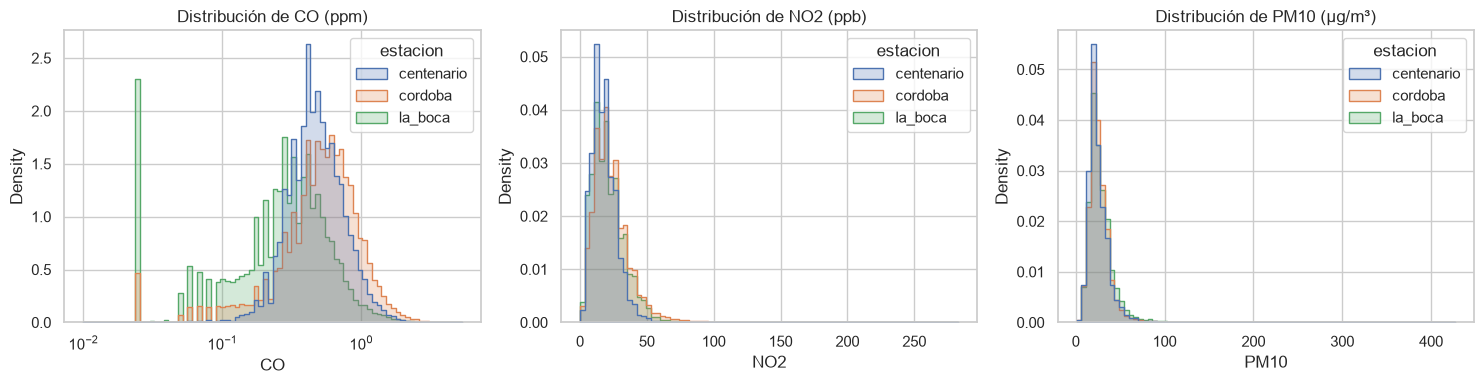

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, p in zip(axes, POLS):
    sns.histplot(data=df, x=p, hue="estacion", element="step", stat="density", common_norm=False, bins=80, ax=ax, log_scale=(p == "CO"))
    ax.set_title(f"Distribución de {p} ({T.POLLUTANTS[p]})")
plt.tight_layout()
print("Asimetría:"); print(df.groupby("estacion")[POLS].skew().round(2))

Las tres distribuciones son asimétricas a derecha (log-normales aprox.): la mediana es más representativa que la media y, para modelar, conviene considerar una transformación logarítmica.

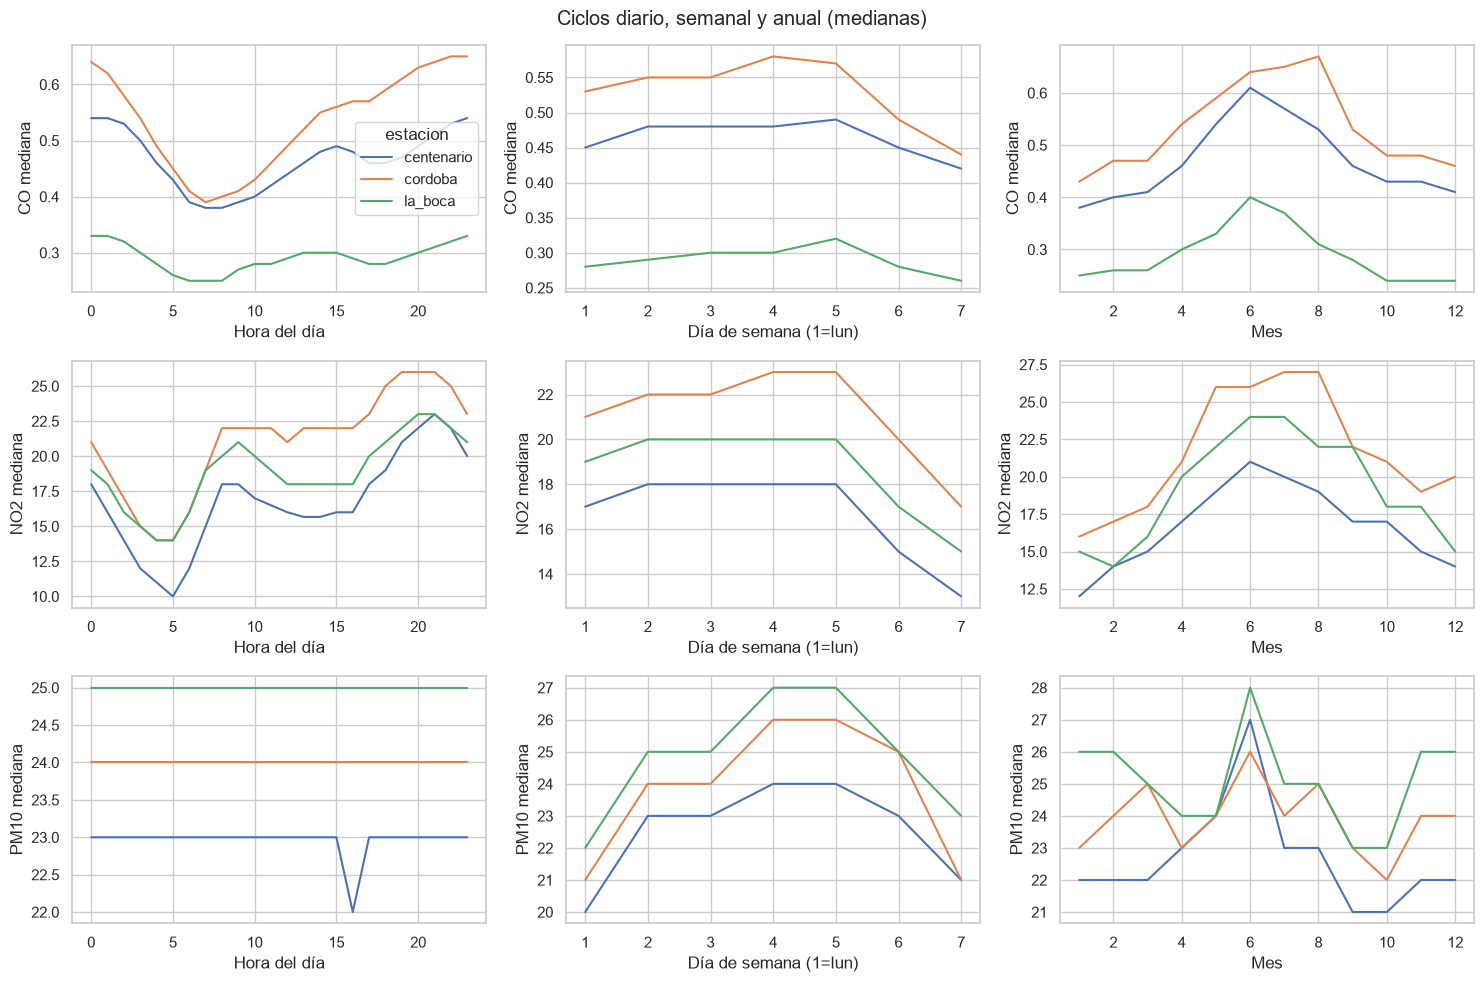

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i, p in enumerate(POLS):
    for j, (col, lab) in enumerate([("hora_dia", "Hora del día"), ("dia_semana", "Día de semana (1=lun)"), ("mes", "Mes")]):
        sns.lineplot(data=df, x=col, y=p, hue="estacion", estimator="median", errorbar=None, ax=axes[i, j], legend=(i == 0 and j == 0))
        axes[i, j].set(xlabel=lab, ylabel=f"{p} mediana")
fig.suptitle("Ciclos diario, semanal y anual (medianas)"); plt.tight_layout()

- **Ciclo diario**: NO2 tiene dos picos (08–09 h y 20–21 h), coincidentes con el tránsito. CO es máximo de noche y mínimo a las 07–08 h (capa de mezcla baja nocturna). PM10 casi no varía en la mediana horaria: sugiere que se publica suavizado (pocos valores distintos por día), a confirmar con la fuente.
- **Ciclo semanal**: menores niveles sábados y domingos.
- **Ciclo anual**: máximos de CO y NO2 en invierno (mayo–agosto, pico en junio), por menor dispersión atmosférica.

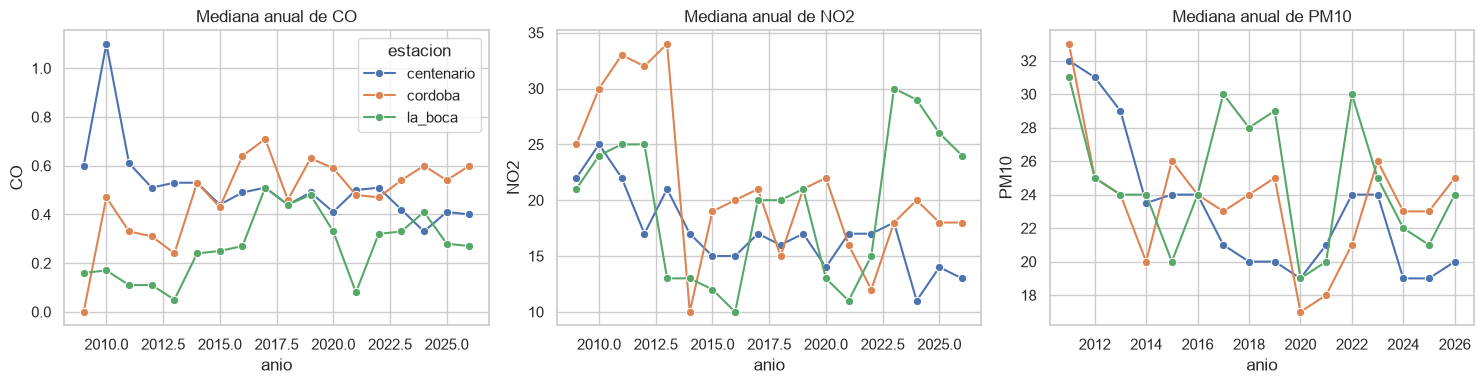

In [17]:
anual = df.groupby(["anio", "estacion"])[POLS].median().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, p in zip(axes, POLS):
    sns.lineplot(data=anual, x="anio", y=p, hue="estacion", marker="o", ax=ax, legend=(p == "CO")); ax.set_title(f"Mediana anual de {p}")
plt.tight_layout()

In [18]:
df["tipo_dia"] = np.select([df.es_dia_no_laborable.eq(1) | df.es_feriado_nacional.eq(1), df.es_fin_de_semana.eq(1)], ["feriado/no laborable", "fin de semana"], "hábil")
df.groupby(["estacion", "tipo_dia"])[POLS].median().round(2).unstack()

CO                                      NO2  \
tipo_dia   feriado/no laborable fin de semana hábil feriado/no laborable   
estacion                                                                   
centenario                 0.42          0.44  0.48                 14.0   
cordoba                    0.42          0.47  0.57                 17.0   
la_boca                    0.25          0.27  0.30                 15.0   

                                               PM10                      
tipo_dia   fin de semana hábil feriado/no laborable fin de semana hábil  
estacion                                                                 
centenario          14.0  18.0                 21.0          22.0  23.0  
cordoba             18.0  23.0                 20.0          23.0  24.0  
la_boca             16.0  20.0                 21.0          24.0  25.0

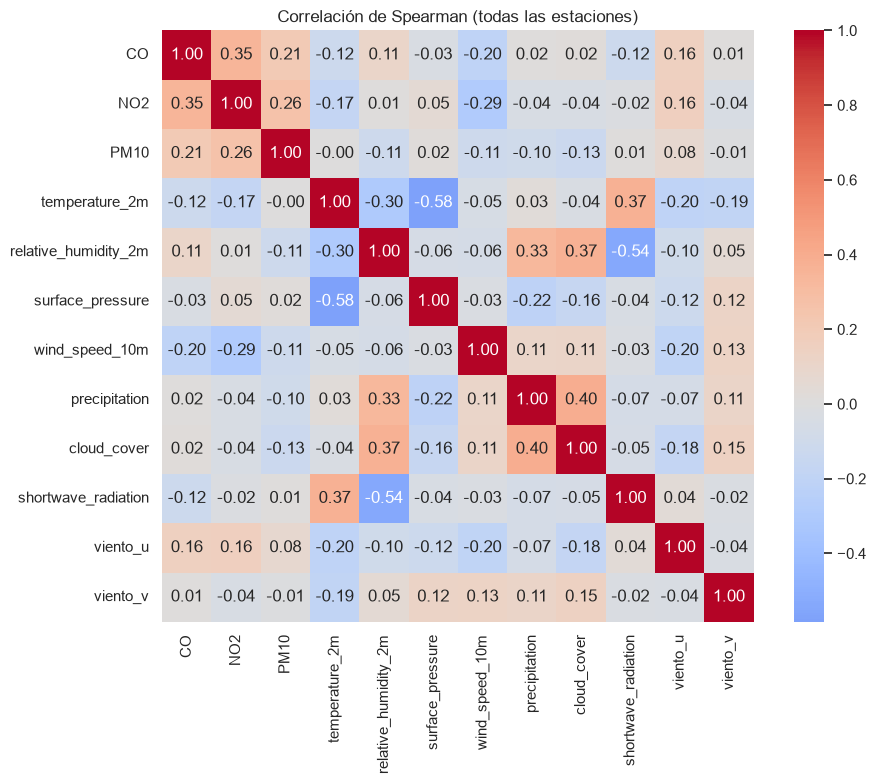

In [19]:
meteo = ["temperature_2m", "relative_humidity_2m", "surface_pressure", "wind_speed_10m", "precipitation", "cloud_cover", "shortwave_radiation", "viento_u", "viento_v"]
corr = df[POLS + meteo].corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlación de Spearman (todas las estaciones)"); plt.tight_layout()

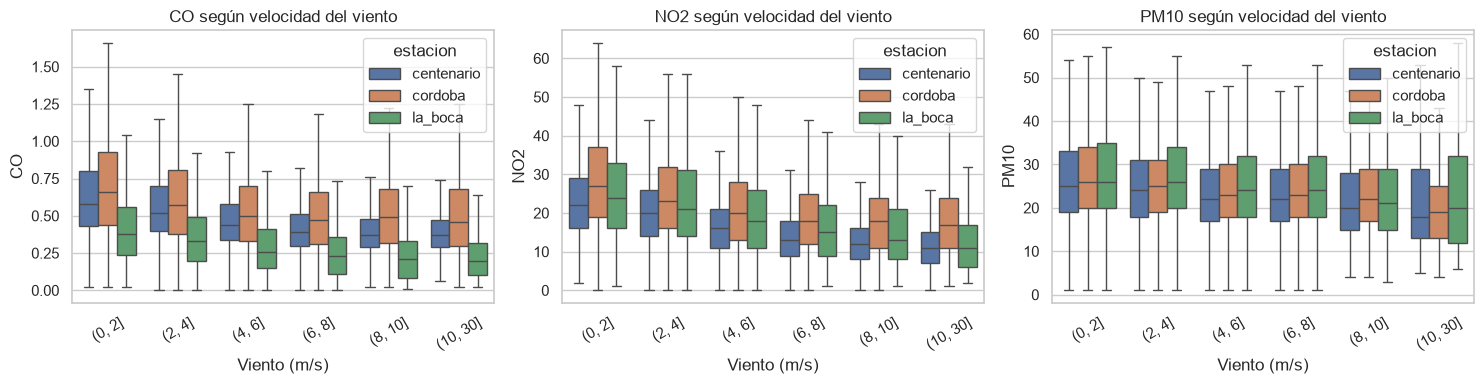

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = pd.cut(df.wind_speed_10m, [0, 2, 4, 6, 8, 10, 30])
for ax, p in zip(axes, POLS):
    sns.boxplot(x=bins, y=df[p], hue=df.estacion, ax=ax, showfliers=False); ax.set(xlabel="Viento (m/s)", title=f"{p} según velocidad del viento")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

**Resultados estadísticos**
- La **velocidad del viento** es la variable meteorológica más asociada (ρ ≈ −0,29 con NO2, −0,20 con CO, −0,11 con PM10): más viento, más dispersión.
- `viento_u` positivo (viento del oeste, desde el continente) se asocia a más CO/NO2 (ρ ≈ 0,16); el viento del este (Río de la Plata) limpia.
- La **temperatura** se correlaciona negativamente con CO/NO2 (ρ ≈ −0,12 / −0,17): el invierno concentra contaminantes.
- PM10 disminuye con precipitación y nubosidad (lavado atmosférico, ρ ≈ −0,10 / −0,13).
- CO y NO2 están positivamente correlacionados (ρ ≈ 0,35, fuente común: tránsito). Las correlaciones son moderadas: las relaciones no son lineales y dependen de la hora y la estación del año.
- Los días hábiles presentan concentraciones mayores que fines de semana y feriados: el calendario aporta información relevante.

## 4. Estrategia para cada caso

| Caso detectado | Cantidad aprox. | Estrategia | Justificación |
|---|---|---|---|
| Filas con HORA = 0 o > 24 | 282 filas | **Eliminar** | Claves inválidas y sin ninguna medición |
| Formato FECHA SAS (`03JAN2021:00:00:00`) y HORA 1–24 | todas | **Convertir** a `fecha_hora` = FECHA + HORA (cierre de la hora) | Convención horaria de la red; HORA 24 → 00 del día siguiente, igual que la unión meteorológica |
| Archivo desordenado / horas ausentes | 2.402 horas | **Ordenar** y reindexar a grilla horaria | Necesario para detectar huecos y congelamientos |
| `s/d`, `S/d`, `x/d`, vacíos | ≈ 740.000 celdas | **Faltante (NaN)**, conservando el motivo en `*_estado` | Unificar marcadores inconsistentes |
| `#REF!` | 288 celdas | **Faltante (NaN)**, estado `error` | Error de planilla, valor irrecuperable |
| Censurados `<LD` | 10.459 celdas | **Sustituir por LD/2** (p. ej. `<0.05` → 0,025) | Criterio estadístico estándar para datos bajo el límite de detección; evita sesgar hacia 0 o LD |
| CO > 10 ppm, NO2 < 0 (fuera de rango físico) | 322 celdas | **Invalidar** (NaN, estado `fuera_rango`) | Errores de registro (saltos ×30 simultáneos) |
| PM10 = 0 | 305 celdas | **Invalidar** | Implausible en promedio horario urbano |
| Mismo valor ≥ 24 h consecutivas | ≈ 1.600 celdas | **Invalidar** (estado `congelado`) | Sensor trabado |
| Atípicos altos plausibles | — | **Conservar** | Son episodios reales de contaminación (objetivo del estudio) |
| Huecos internos ≤ 3 h | ≈ 2.800 celdas | **Imputar por interpolación lineal** (estado `interpolado`) | Series con fuerte autocorrelación horaria; error pequeño |
| Huecos > 3 h | resto | **No imputar** (NaN) | Bloques largos: imputar inventaría episodios; se filtran al elegir el contaminante objetivo |
| Estación-hora sin ningún contaminante | ≈ 38.000 filas | **Eliminar** | No aportan variable objetivo |
| Estación Palermo | 5.942 filas | **Excluir** | Sólo CO en 11 meses, sin NO2/PM10, desactivada |
| Meteorología ausente / fuera de rango | 0 filas finales | Interpolar ≤ 3 h, si no, eliminar fila | ERA5 completa: no fue necesario |

## 5. Unificación de fuentes y selección de columnas/filas

**Unificación** (`run.ps1 join`): left join desde aire con meteorología (por estación, fecha y hora) y calendario/feriados (por fecha). Resultado: 145.980 filas × 89 columnas, formato ancho.

**Transformación** (`run.ps1 transform`):
1. Pasaje de formato **ancho a largo**: una fila por **estación-hora**; así cada fila tiene sus propios contaminantes y su meteorología, y la estación pasa a ser una variable.
2. Selección de **filas**: estaciones Centenario, Córdoba y La Boca; horas válidas; al menos un contaminante.
3. Selección de **columnas**: se descartan las columnas de procedencia (`fecha_hora_fuente`, `tipo_hora`, `estado`), los textos y detalles de feriados (`FERIADO_*`, nombres, fuentes) y `wind_direction_10m`.
4. Variables derivadas mínimas: `viento_u`, `viento_v` (la dirección es circular: 359° y 1° son casi iguales; las componentes lo resuelven), `anio`, `mes`, `hora_dia`, `estacion_anio`, `dia_semana`, indicadores de fin de semana/feriado/no laborable.

In [21]:
print(f"Entrada: {entrada.shape[0]} filas × {entrada.shape[1]} columnas (formato ancho)")
print(f"Salida:  {df.shape[0] - 0} filas × {len(meta['output']['columns'])} columnas (formato largo estación-hora)")
flujo = pd.DataFrame({k: {"filas CSV": v["filas_csv"], "sin contaminantes (eliminadas)": v["filas_sin_contaminantes_descartadas"],
                          "sin meteorología (eliminadas)": v["filas_sin_meteorologia_descartadas"], "filas finales": v["filas_finales"]}
                      for k, v in meta["reporte"]["estaciones"].items()}).T
flujo

Entrada: 145980 filas × 89 columnas (formato ancho)
Salida:  398961 filas × 27 columnas (formato largo estación-hora)


,filas CSV,sin contaminantes (eliminadas),sin meteorología (eliminadas),filas finales
centenario,145698,9236,0,136462
cordoba,145698,17878,0,127820
la_boca,145698,11019,0,134679


In [22]:
rows = []
for s, info in meta["reporte"]["estaciones"].items():
    for p in POLS:
        i = info[p]
        rows.append({"estación": s, "contaminante": p, **{k: i["inicial"].get(k, 0) for k in ["medido", "censurado", "sin_dato", "vacio", "error"]},
                     "fuera_rango": i["fuera_rango"], "congelado": i["congelado"], "interpolado": i["interpolado"],
                     "faltante final": info["faltantes_finales"][p]})
pd.DataFrame(rows).set_index(["estación", "contaminante"])

medido  censurado  sin_dato  vacio  error  \
estación   contaminante                                              
centenario CO            115975         21     29643     11     48   
           NO2           116233          0     29431     10     24   
           PM10          118337          0     17022  10315     24   
cordoba    CO            110542       1774     33323     11     48   
           NO2            97127          0     48536     11     24   
           PM10           99586          0     35773  10315     24   
la_boca    CO            102338       8664     34639      9     48   
           NO2           119842          0     25822     10     24   
           PM10          114736          0     20626  10312     24   

                         fuera_rango  congelado  interpolado  faltante final  
estación   contaminante                                                       
centenario CO                    103        111            6           20674  
           NO2                     1         48         1494           18784  
           PM10                   80        409           18           18596  
cordoba    CO                     96        116           11           15705  
           NO2                     0         48          576           30165  
           PM10                  121        322            5           28672  
la_boca    CO                    122         74           43           23830  
           NO2                     0         72          677           14232  
           PM10                  104        374            9           20412

## 6. Dataset objetivo
`data/exports/dataset_objetivo.csv` (+ `dataset_objetivo.meta.json` con hashes, decisiones y conteos).

In [23]:
df = df.drop(columns="tipo_dia")
diccionario = pd.DataFrame({"tipo": df.dtypes.astype(str), "% nulos": (df.isna().mean() * 100).round(2), "ejemplo": df.iloc[0]})
diccionario

,tipo,% nulos,ejemplo
estacion,str,0.00,centenario
fecha_hora,datetime64[us],0.00,2009-10-01 17:00:00
fecha,str,0.00,2009-10-01
hora_original,int64,0.00,17
anio,int64,0.00,2009
mes,int64,0.00,10
dia_semana,int64,0.00,4
hora_dia,int64,0.00,17
estacion_anio,str,0.00,primavera
es_fin_de_semana,int64,0.00,0


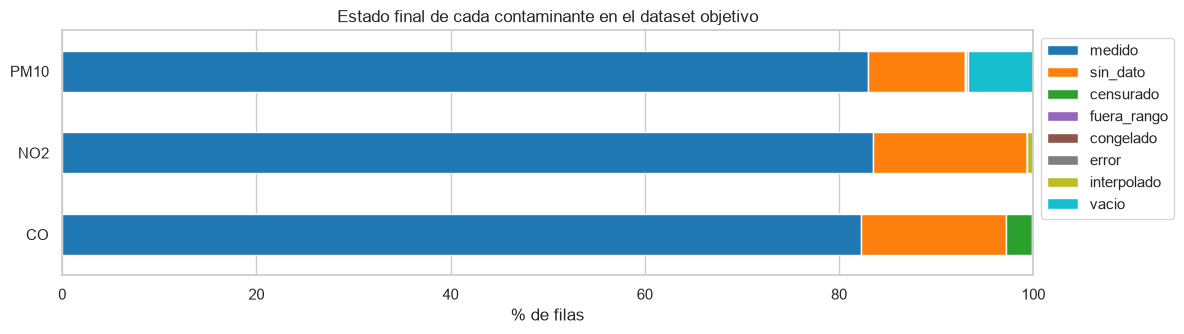

In [24]:
estado = pd.concat({p: df[f"{p}_estado"].value_counts(normalize=True) * 100 for p in POLS}, axis=1).fillna(0).round(2)
ax = estado.T.plot.barh(stacked=True, figsize=(12, 3.5), colormap="tab10"); ax.set_xlabel("% de filas"); ax.legend(bbox_to_anchor=(1, 1))
ax.set_title("Estado final de cada contaminante en el dataset objetivo"); plt.tight_layout()

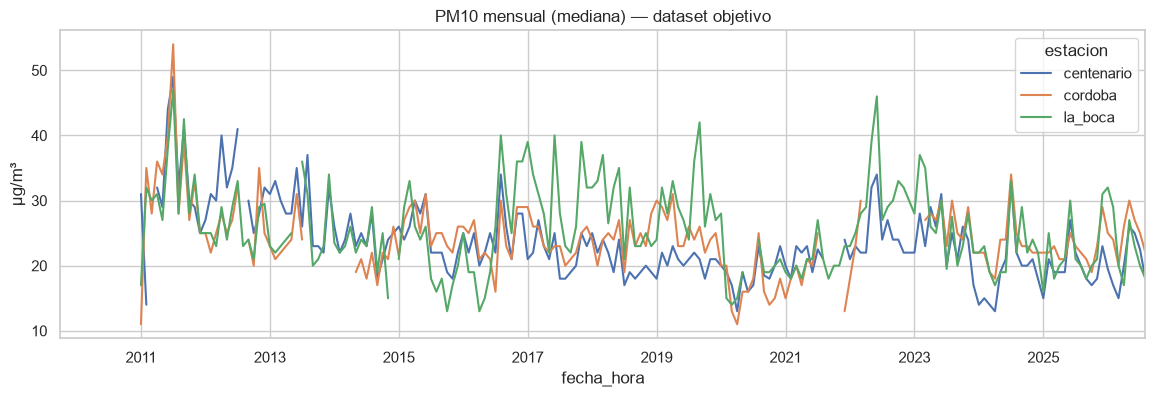

In [25]:
fig, ax = plt.subplots(figsize=(14, 4))
(df.set_index("fecha_hora").groupby("estacion")["PM10"].resample("MS").median().unstack(0)).plot(ax=ax)
ax.set(title="PM10 mensual (mediana) — dataset objetivo", ylabel="µg/m³");

### Conclusiones
- El dataset objetivo tiene **398.961 filas estación-hora** (3 estaciones, 10/2009–08/2026) y 27 columnas: 2 de identificación (estación, fecha_hora), 10 de calendario/tiempo, 3 contaminantes con su estado y 9 variables meteorológicas.
- Todas las decisiones son trazables: cada valor conserva su `*_estado` y el `.meta.json` registra hashes de entrada/salida y conteos.
- Para modelar un contaminante se filtran las filas con ese valor no nulo; opcionalmente se excluyen `interpolado` y `censurado` para análisis de sensibilidad.
- Pendientes para la siguiente entrega: transformación log de contaminantes, variables rezagadas (lags) y partición temporal train/test (sin mezclar años para evitar fuga de información).